In [173]:
#import libraries
import boto3
import awswrangler as wr
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
#import data from s3 bucket
session = boto3.Session(region_name="us-east-1")
s3 = session.client("s3")
df = wr.s3.read_json(path="s3://imungai-capstone/analytics/regression_dataset/",lines=True ,boto3_session = session)
df.head(10)

,ed_length_of_stay_minutes,sepsis_care_compliance,emergency_services,pulmonary_embolism_dvt_rate,recommend_hospital,hospital_name,doctor_communication,cleanliness_score,ed_volume,wound_dehiscence_rate,...,postop_sepsis_rate,pressure_ulcer_rate,medication_communication,healthcare_worker_flu_vaccination,nurse_communication,hospital_type,facility_id,opioid_safety_compliance,postop_respiratory_failure_rate,hospital_overall_rating
0,198.0,53.0,Yes,3.097856,4,BAPTIST HEALTH HARDIN,4,3,very high,1.957114,...,8.188547,1.016141,3,86.0,4,Acute Care Hospitals,180012,11.0,8.131374,3
1,160.0,59.0,No,3.197621,4,OSF SAINT ANTHONY'S HEALTH CENTER,3,4,medium,1.741294,...,NaN,0.382504,3,86.0,4,Acute Care Hospitals,140052,20.0,NaN,4
2,173.0,67.0,No,3.949943,3,SOUTH POINTE HOSPITAL,3,4,medium,1.704001,...,4.972340,0.485347,2,86.0,3,Acute Care Hospitals,360144,10.0,10.925646,5
3,170.0,57.0,Yes,NaN,1,HOLY CROSS HOSPITAL,2,2,medium,NaN,...,NaN,0.398981,1,96.0,1,Acute Care Hospitals,140133,9.0,NaN,2
4,194.0,30.0,Yes,3.515867,4,HEYWOOD HOSPITAL -,3,4,low,1.729335,...,5.128679,0.722683,3,70.0,4,Acute Care Hospitals,220095,18.0,8.911294,2
5,118.0,81.0,Yes,4.981721,3,"PRAIRIE LAKES HEALTHCARE SYSTEM, INC",4,3,low,2.074030,...,5.808065,1.560986,3,51.0,4,Acute Care Hospitals,430005,16.0,7.774145,3
6,162.0,52.0,Yes,2.814201,4,GEISINGER MEDICAL CENTER,3,4,very high,1.514315,...,4.363343,0.968728,3,95.0,4,Acute Care Hospitals,390006,15.0,8.369203,4
7,127.0,27.0,Yes,3.454621,4,MERIT HEALTH MADISON,4,4,low,1.736101,...,NaN,0.505820,3,43.0,4,Acute Care Hospitals,250038,17.0,NaN,3
8,136.0,63.0,Yes,3.363070,5,CARY MEDICAL CENTER,4,3,low,2.075345,...,NaN,0.528358,5,99.0,4,Acute Care Hospitals,200031,22.0,NaN,1
9,258.0,64.0,Yes,3.519903,2,USC ARCADIA HOSPITAL,2,3,high,2.292890,...,7.950541,0.701277,1,90.0,2,Acute Care Hospitals,50238,15.0,15.284427,3


In [175]:
print(df.dtypes)

ed_length_of_stay_minutes            float64
sepsis_care_compliance               float64
emergency_services                    object
pulmonary_embolism_dvt_rate          float64
recommend_hospital                     int64
hospital_name                         object
doctor_communication                   int64
cleanliness_score                      int64
ed_volume                             object
wound_dehiscence_rate                float64
state                                 object
region                                object
discharge_information                  int64
hospital_ownership                    object
infection_index                      float64
postop_sepsis_rate                   float64
pressure_ulcer_rate                  float64
medication_communication               int64
healthcare_worker_flu_vaccination    float64
nurse_communication                    int64
hospital_type                         object
facility_id                            int64
opioid_saf

In [176]:
#fix facility_id from int to string
df["facility_id"] = (df["facility_id"].astype("Int64").astype(str).str.zfill(6))
df["facility_id"].sample(10)

14    520103
22    220100
17    340127
26    150101
54    450801
5     500053
21    180013
48    450617
38    500129
57    390037
Name: facility_id, dtype: object

In [177]:
#create numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()
numerical_columns

['ed_length_of_stay_minutes',
 'sepsis_care_compliance',
 'pulmonary_embolism_dvt_rate',
 'recommend_hospital',
 'doctor_communication',
 'cleanliness_score',
 'wound_dehiscence_rate',
 'discharge_information',
 'infection_index',
 'postop_sepsis_rate',
 'pressure_ulcer_rate',
 'medication_communication',
 'healthcare_worker_flu_vaccination',
 'nurse_communication',
 'opioid_safety_compliance',
 'postop_respiratory_failure_rate',
 'hospital_overall_rating']

In [178]:
#summary statistics for numerical values
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ed_length_of_stay_minutes,2395.0,181.015866,47.440247,76.000000,146.000000,175.000000,208.000000,464.000000
sepsis_care_compliance,2389.0,63.191712,14.643677,0.000000,54.000000,64.000000,74.000000,100.000000
pulmonary_embolism_dvt_rate,2363.0,3.523158,0.744318,1.312994,3.093052,3.400793,3.856682,8.140423
recommend_hospital,2396.0,3.436978,1.044617,1.000000,3.000000,4.000000,4.000000,5.000000
doctor_communication,2396.0,3.071786,0.746782,1.000000,3.000000,3.000000,4.000000,5.000000
cleanliness_score,2396.0,3.163189,0.934871,1.000000,3.000000,3.000000,4.000000,5.000000
wound_dehiscence_rate,2168.0,1.767622,0.228710,0.841201,1.660128,1.717382,1.785620,3.541568
discharge_information,2396.0,3.177796,0.953241,1.000000,3.000000,3.000000,4.000000,5.000000
infection_index,2396.0,0.553131,0.356418,0.000000,0.312600,0.536100,0.741850,3.008000
postop_sepsis_rate,2046.0,5.345327,1.145184,1.150455,4.728701,5.120195,5.855280,12.273747


In [179]:
#create categorical columns
categorical_columns = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
categorical_columns

['emergency_services',
 'hospital_name',
 'ed_volume',
 'state',
 'region',
 'hospital_ownership',
 'hospital_type',
 'facility_id']

In [180]:
#summary statistics for categorical variables
print(df["emergency_services"].value_counts(), "\n")
print(df["region"].value_counts(), "\n")
print(df["hospital_ownership"].value_counts(), "\n")
print(df["hospital_type"].value_counts(), "\n")
print(df["ed_volume"].value_counts(), "\n")

emergency_services
Yes    2298
No       98
Name: count, dtype: int64 

region
South        959
Midwest      561
West         474
Northeast    402
Name: count, dtype: int64 

hospital_ownership
Voluntary non-profit - Private                 1260
Proprietary                                     437
Voluntary non-profit - Other                    204
Voluntary non-profit - Church                   170
Government - Hospital District or Authority     164
Government - Local                              107
Government - State                               34
Physician                                        13
Government - Federal                              7
Name: count, dtype: int64 

hospital_type
Acute Care Hospitals    2396
Name: count, dtype: int64 

ed_volume
medium       824
very high    694
high         540
low          338
Name: count, dtype: int64 



In [181]:
#check for missing values
print(df.isna().sum())

ed_length_of_stay_minutes              1
sepsis_care_compliance                 7
emergency_services                     0
pulmonary_embolism_dvt_rate           33
recommend_hospital                     0
hospital_name                          0
doctor_communication                   0
cleanliness_score                      0
ed_volume                              0
wound_dehiscence_rate                228
state                                  0
region                                 0
discharge_information                  0
hospital_ownership                     0
infection_index                        0
postop_sepsis_rate                   350
pressure_ulcer_rate                    0
medication_communication               0
healthcare_worker_flu_vaccination      5
nurse_communication                    0
hospital_type                          0
facility_id                            0
opioid_safety_compliance              34
postop_respiratory_failure_rate      315
hospital_overall

In [182]:
#drop irrelevant columns
df_model = df.drop(columns=["hospital_type", "facility_id", "hospital_name", "state"]).copy()

In [183]:
#impute missing numerical values with the median
numerical_cols = list(set(numerical_columns) - {"infection_index", "vte_prophylaxis_compliance"})
imputer = SimpleImputer(strategy="median")
df_model[numerical_cols] = imputer.fit_transform(df[numerical_cols])
print(df_model.isna().sum())

ed_length_of_stay_minutes            0
sepsis_care_compliance               0
emergency_services                   0
pulmonary_embolism_dvt_rate          0
recommend_hospital                   0
doctor_communication                 0
cleanliness_score                    0
ed_volume                            0
wound_dehiscence_rate                0
region                               0
discharge_information                0
hospital_ownership                   0
infection_index                      0
postop_sepsis_rate                   0
pressure_ulcer_rate                  0
medication_communication             0
healthcare_worker_flu_vaccination    0
nurse_communication                  0
opioid_safety_compliance             0
postop_respiratory_failure_rate      0
hospital_overall_rating              0
dtype: int64


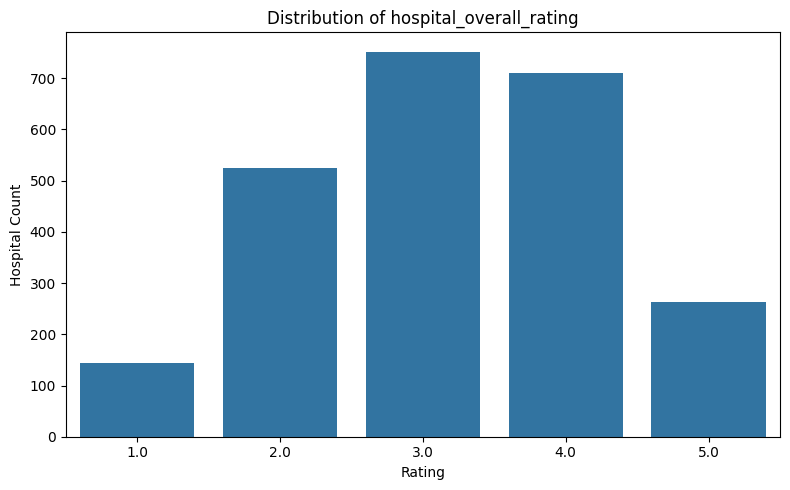

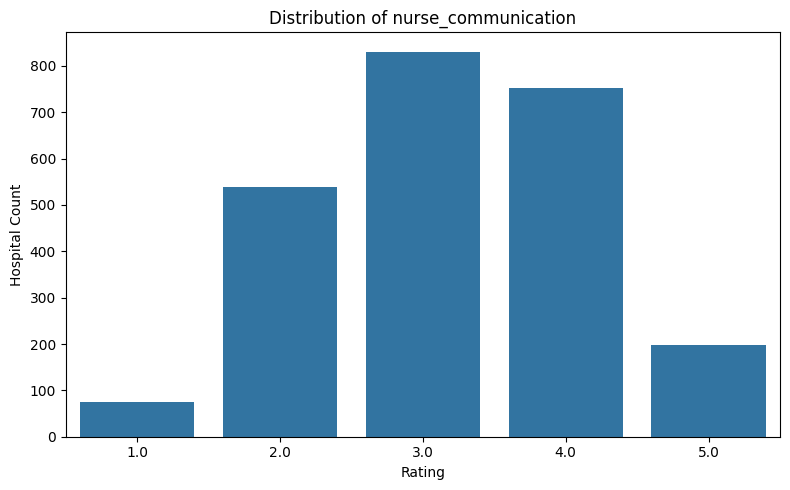

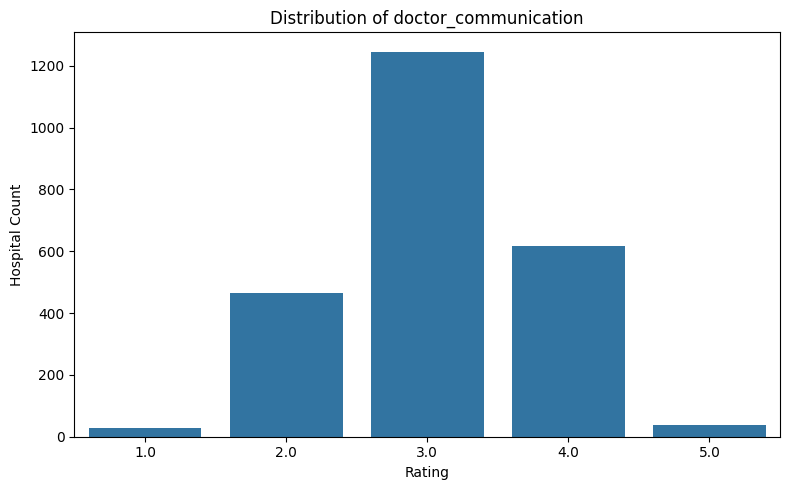

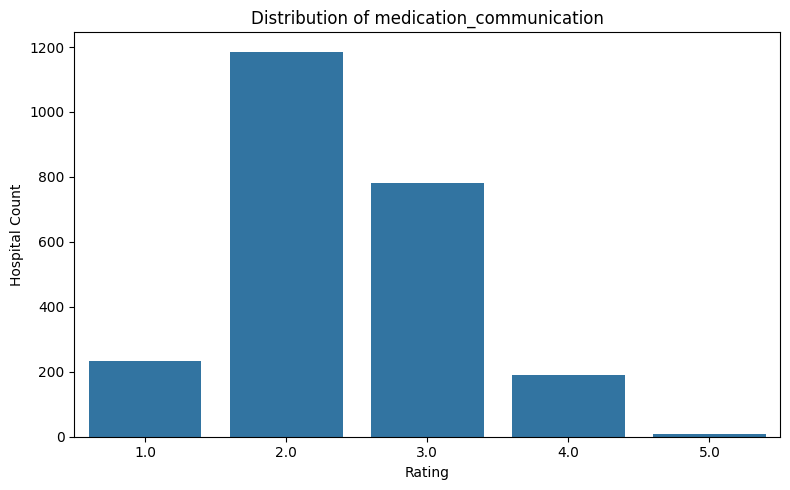

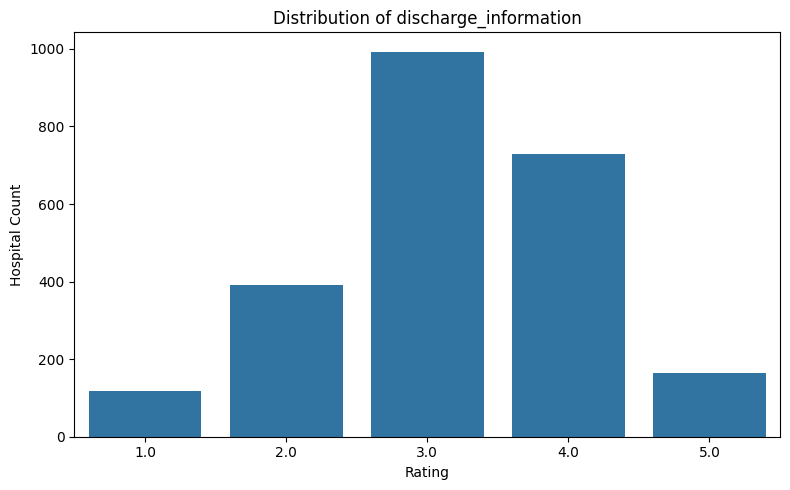

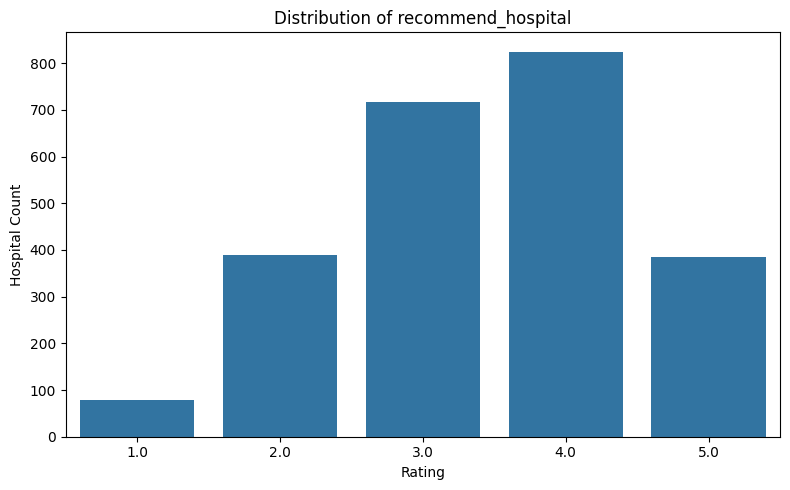

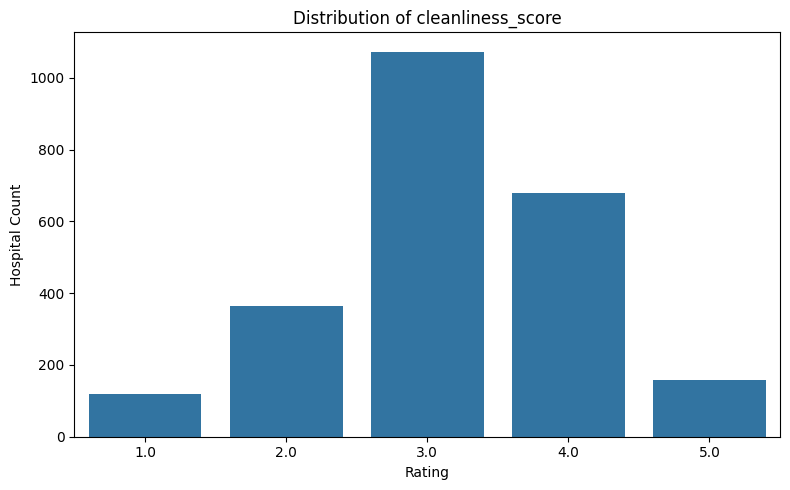

In [184]:
ordinal_columns = ["hospital_overall_rating", "nurse_communication", "doctor_communication", "medication_communication", "discharge_information", "recommend_hospital", "cleanliness_score"]
for col in ordinal_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_model,x=col,order=sorted(df_model[col].dropna().unique()))
    plt.title(f"Distribution of {col}")
    plt.xlabel("Rating")
    plt.ylabel("Hospital Count")
    plt.tight_layout()
    plt.show()

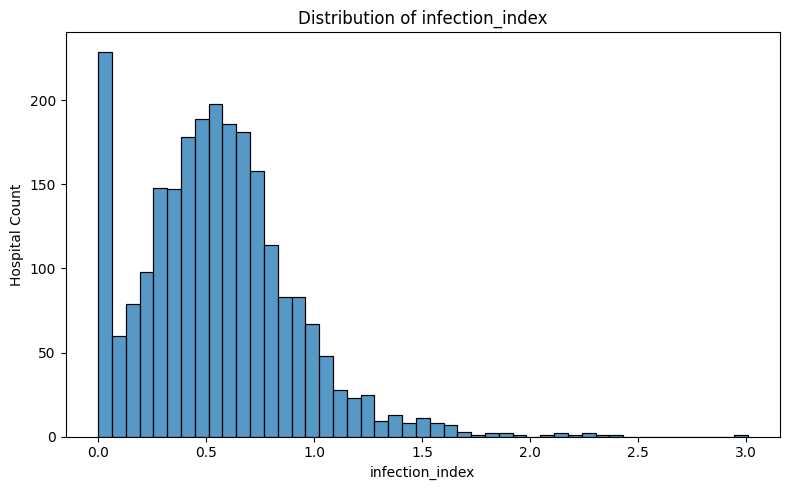

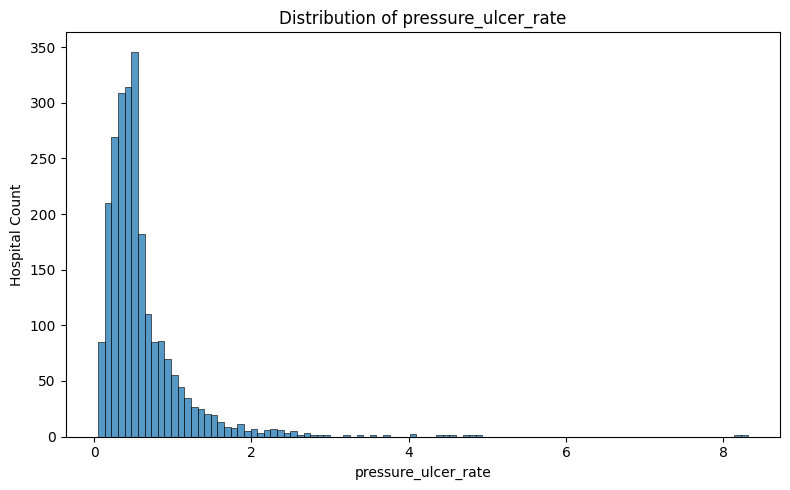

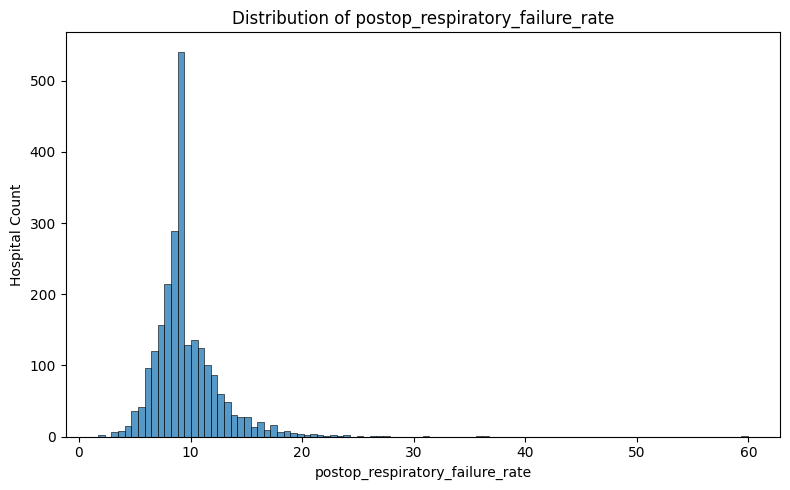

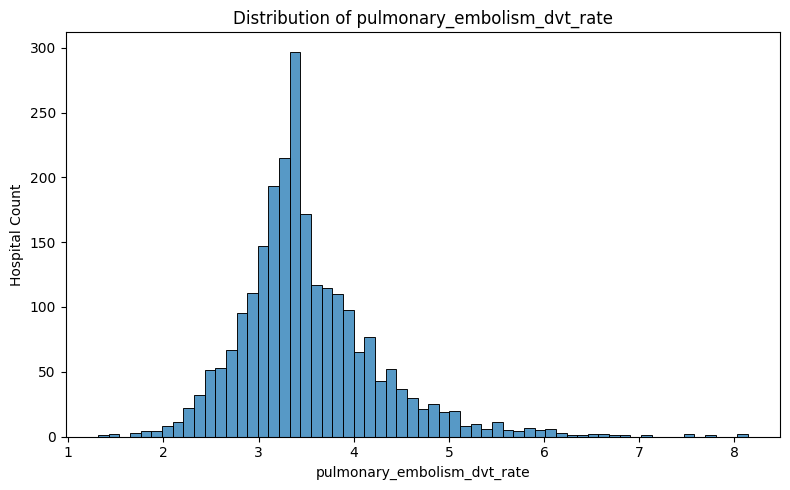

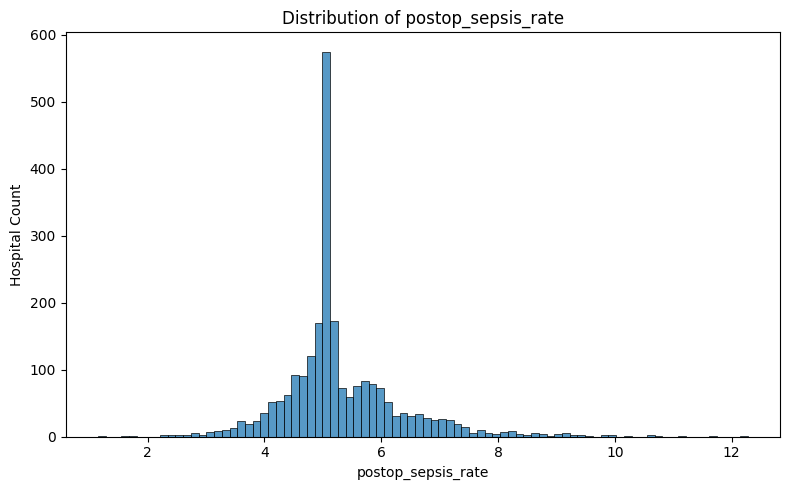

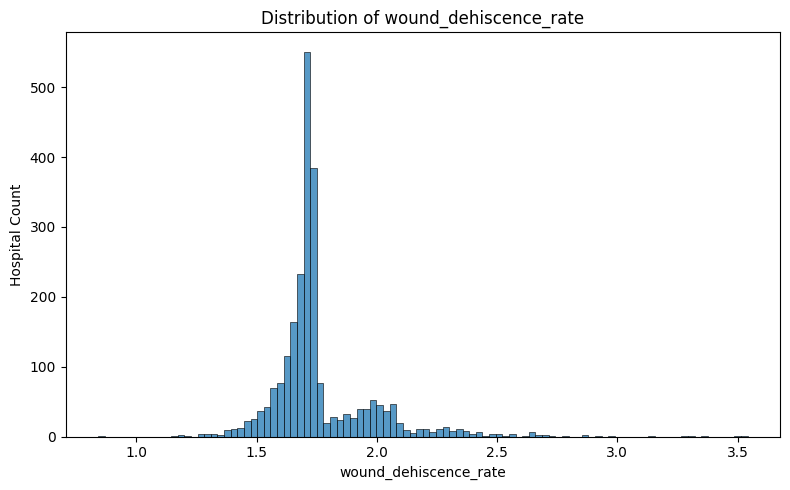

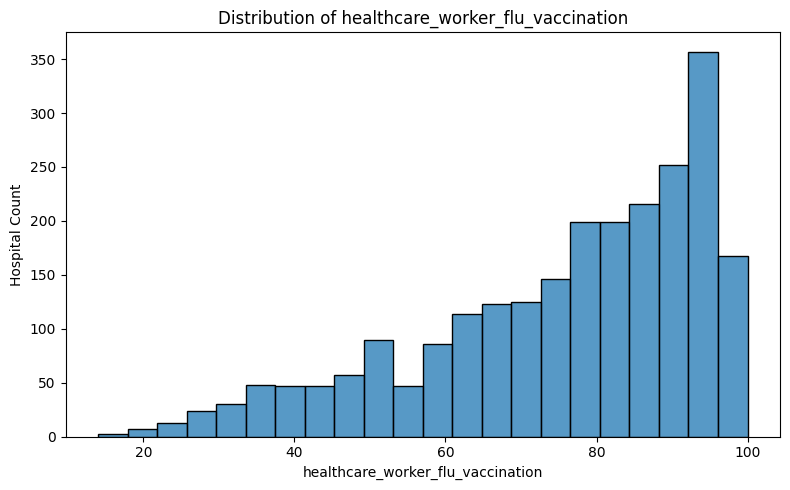

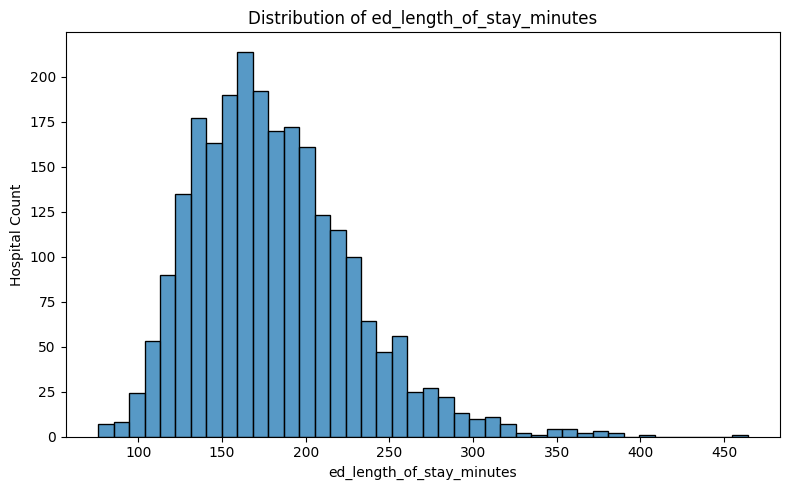

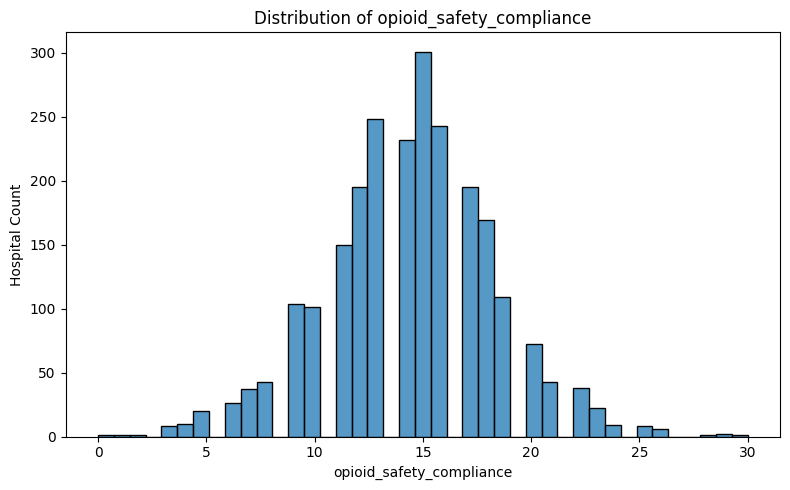

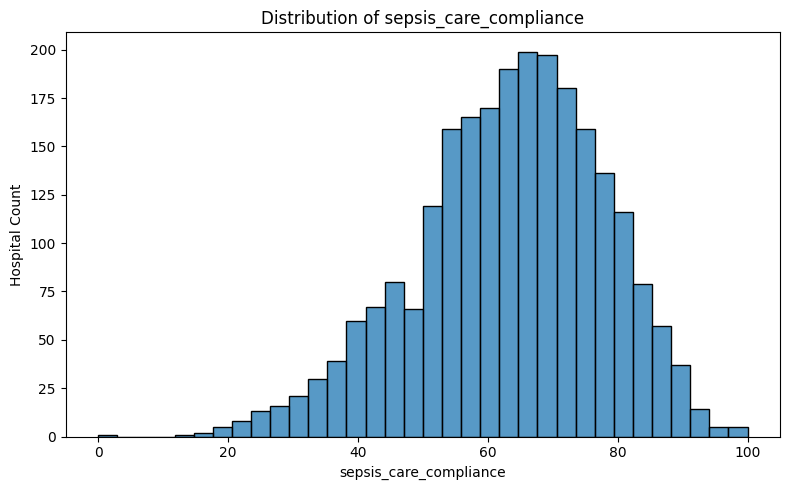

In [185]:
continuous_columns = ["infection_index", "pressure_ulcer_rate", "postop_respiratory_failure_rate", "pulmonary_embolism_dvt_rate", "postop_sepsis_rate", "wound_dehiscence_rate", "healthcare_worker_flu_vaccination", "ed_length_of_stay_minutes", "opioid_safety_compliance", "sepsis_care_compliance"]
for col in continuous_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_model,x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Hospital Count")
    plt.tight_layout()
    plt.show()

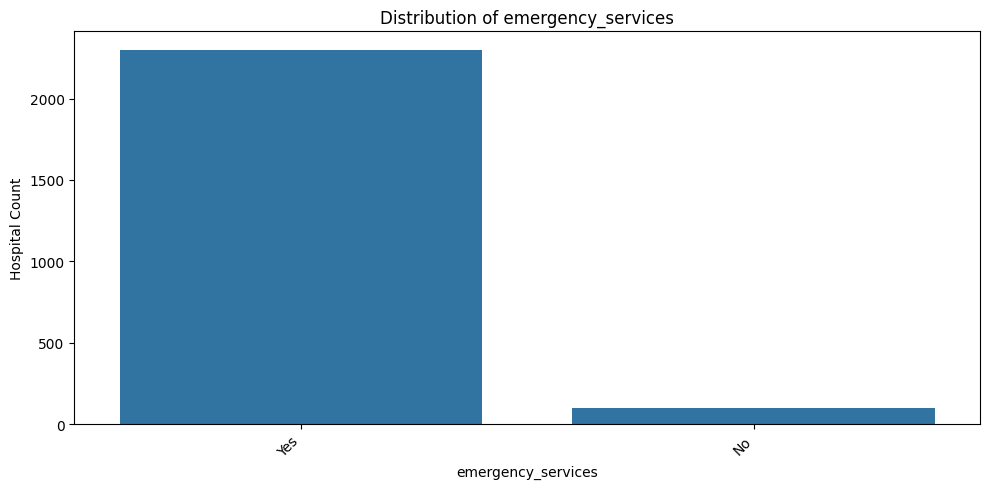

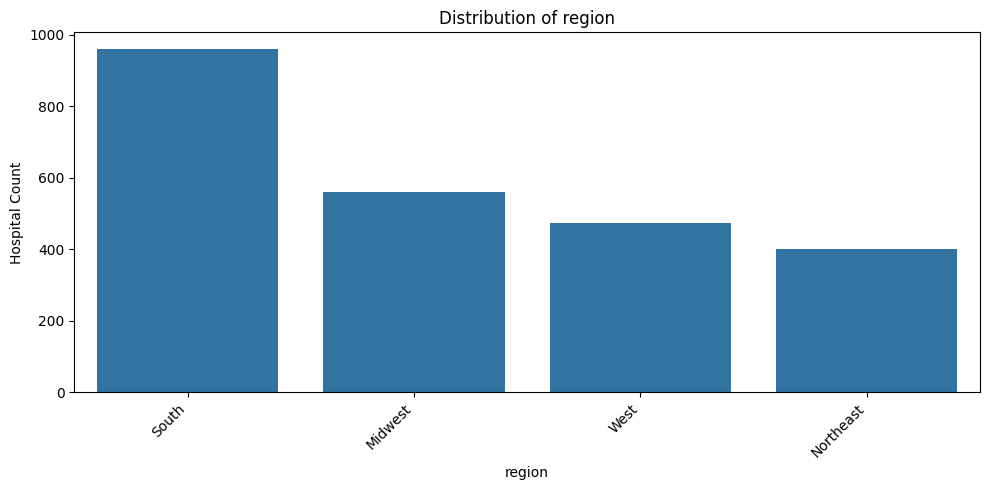

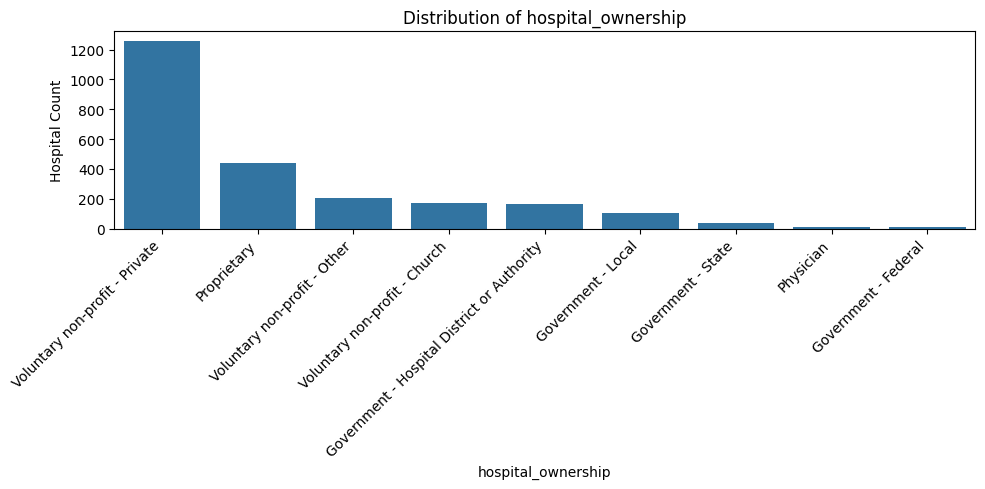

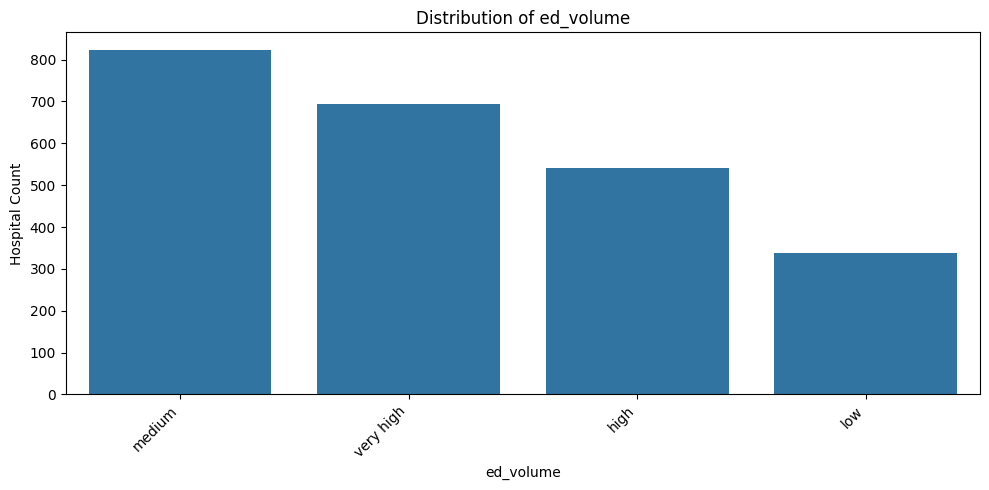

In [186]:
categorical_columns = ["emergency_services", "region", "hospital_ownership", "ed_volume"]
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_model,x=col,order=df_model[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Hospital Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [187]:
#find outliers and cap them
cap_columns = ["wound_dehiscence_rate", "postop_sepsis_rate", "pressure_ulcer_rate", "postop_respiratory_failure_rate"]
for col in cap_columns:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_model[col] = df_model[col].clip(lower=lower,upper=upper)
df_model.sample(5)

,ed_length_of_stay_minutes,sepsis_care_compliance,emergency_services,pulmonary_embolism_dvt_rate,recommend_hospital,doctor_communication,cleanliness_score,ed_volume,wound_dehiscence_rate,region,...,hospital_ownership,infection_index,postop_sepsis_rate,pressure_ulcer_rate,medication_communication,healthcare_worker_flu_vaccination,nurse_communication,opioid_safety_compliance,postop_respiratory_failure_rate,hospital_overall_rating
57,177.0,57.0,Yes,2.613568,3.0,3.0,3.0,high,1.671376,Northeast,...,Voluntary non-profit - Private,0.850000,6.117531,0.335884,3.0,91.0,4.0,15.0,7.603005,4.0
11,164.0,75.0,Yes,4.544393,4.0,4.0,3.0,very high,1.538637,South,...,Voluntary non-profit - Church,0.578800,4.601247,0.180806,2.0,76.0,4.0,18.0,9.267865,3.0
64,252.0,50.0,Yes,3.898626,4.0,3.0,3.0,medium,1.881734,Northeast,...,Voluntary non-profit - Private,0.887400,6.518576,1.285078,2.0,97.0,4.0,18.0,10.675743,2.0
1,229.0,56.0,Yes,4.729609,4.0,3.0,2.0,high,1.628082,South,...,Voluntary non-profit - Private,0.925833,6.103438,0.181192,2.0,50.0,2.0,13.0,10.658104,3.0
25,274.0,44.0,Yes,3.022210,5.0,4.0,3.0,high,1.677241,Northeast,...,Voluntary non-profit - Other,0.307000,5.114943,0.210732,3.0,94.0,4.0,15.0,8.630105,4.0


In [188]:
#encode categorical data
df_encoded = pd.get_dummies(df_model,columns=["emergency_services", "region", "hospital_ownership", "ed_volume"], drop_first=True, dtype=int)
df_encoded.dropna(inplace=True)
df_encoded.sample(5)

,ed_length_of_stay_minutes,sepsis_care_compliance,pulmonary_embolism_dvt_rate,recommend_hospital,doctor_communication,cleanliness_score,wound_dehiscence_rate,discharge_information,infection_index,postop_sepsis_rate,...,hospital_ownership_Government - Local,hospital_ownership_Government - State,hospital_ownership_Physician,hospital_ownership_Proprietary,hospital_ownership_Voluntary non-profit - Church,hospital_ownership_Voluntary non-profit - Other,hospital_ownership_Voluntary non-profit - Private,ed_volume_low,ed_volume_medium,ed_volume_very high
59,144.0,73.0,3.371052,3.0,4.0,2.0,1.717382,3.0,0.0000,5.120195,...,0,0,0,0,0,0,1,1,0,0
47,325.0,57.0,4.100228,4.0,3.0,3.0,1.881734,3.0,0.4715,7.060422,...,1,0,0,0,0,0,0,0,0,1
58,189.0,66.0,2.313937,4.0,3.0,2.0,1.881734,2.0,0.3274,5.628916,...,0,0,0,0,0,0,1,0,0,1
65,156.0,65.0,2.757181,3.0,3.0,3.0,1.673332,2.0,0.1164,6.256710,...,0,0,0,1,0,0,0,0,0,0
4,177.0,69.0,4.128582,5.0,3.0,4.0,1.545213,3.0,0.6790,5.243910,...,0,0,0,0,0,1,0,0,0,1


In [189]:
print(df_encoded.dtypes)

ed_length_of_stay_minutes                                         float64
sepsis_care_compliance                                            float64
pulmonary_embolism_dvt_rate                                       float64
recommend_hospital                                                float64
doctor_communication                                              float64
cleanliness_score                                                 float64
wound_dehiscence_rate                                             float64
discharge_information                                             float64
infection_index                                                   float64
postop_sepsis_rate                                                float64
pressure_ulcer_rate                                               float64
medication_communication                                          float64
healthcare_worker_flu_vaccination                                 float64
nurse_communication                   

In [190]:
#split the data
X = df_encoded.drop("infection_index", axis=1)
y = df_encoded["infection_index"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1916, 31)
Testing set shape: (480, 31)


In [191]:
#create the initial model
X_train_const = sm.add_constant(X_train)
initial_model = sm.OLS(y_train, X_train_const).fit()
print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:        infection_index   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     7.699
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.40e-31
Time:                        15:12:14   Log-Likelihood:                -613.51
No. Observations:                1916   AIC:                             1291.
Df Residuals:                    1884   BIC:                             1469.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [192]:
#optimize model using backward stepwise elimination
X_opt = X_train_const.copy()
removed_variables = []
while True:
    model = sm.OLS(y_train, X_opt).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    if max_p > 0.05:
        var_to_remove = p_values.idxmax()
        removed_variables.append(var_to_remove)
        X_opt = X_opt.drop(columns=[var_to_remove])
        print("Removed variable:", var_to_remove, "\n")
    else:
        break
optimized_model = sm.OLS(y_train, X_opt).fit()

Removed variable: hospital_ownership_Voluntary non-profit - Private 

Removed variable: hospital_ownership_Voluntary non-profit - Church 

Removed variable: discharge_information 

Removed variable: doctor_communication 

Removed variable: cleanliness_score 

Removed variable: nurse_communication 

Removed variable: wound_dehiscence_rate 

Removed variable: opioid_safety_compliance 

Removed variable: sepsis_care_compliance 

Removed variable: pressure_ulcer_rate 

Removed variable: medication_communication 

Removed variable: hospital_ownership_Government - Hospital District or Authority 

Removed variable: hospital_ownership_Government - State 

Removed variable: postop_respiratory_failure_rate 

Removed variable: postop_sepsis_rate 

Removed variable: hospital_ownership_Voluntary non-profit - Other 

Removed variable: hospital_ownership_Physician 

Removed variable: emergency_services_Yes 

Removed variable: ed_volume_very high 

Removed variable: hospital_ownership_Government - Loc

In [193]:
#save optimized model
print(optimized_model.summary())
joblib.dump(optimized_model, "hospital_hai_linear_regression_model.pkl")

                            OLS Regression Results                            
Dep. Variable:        infection_index   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     19.56
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           9.25e-38
Time:                        15:12:14   Log-Likelihood:                -625.20
No. Observations:                1916   AIC:                             1274.
Df Residuals:                    1904   BIC:                             1341.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

['hospital_hai_linear_regression_model.pkl']

In [194]:
#model prediction
X_test_opt = sm.add_constant(X_test[X_opt.columns.drop('const')])
y_pred = optimized_model.predict(X_test_opt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Square Error: ", rmse)

Root Mean Square Error:  0.334586774638517


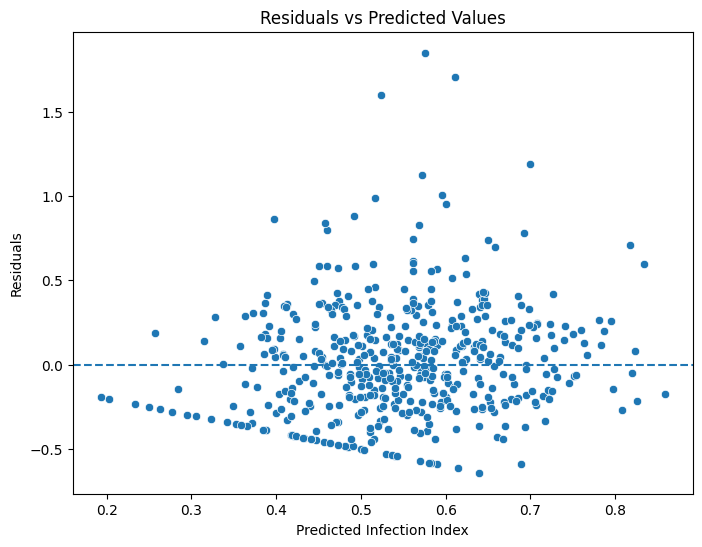

In [197]:
#linearity and homoscedasticity check
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(y=0,linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Infection Index")
plt.ylabel("Residuals")
plt.show()

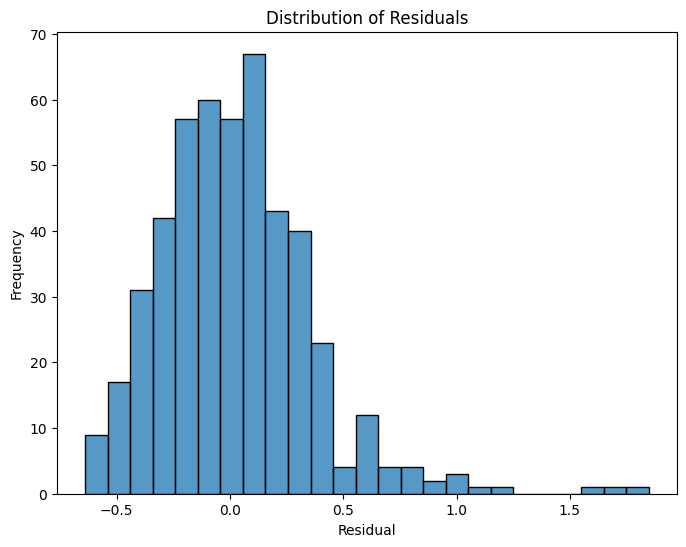

In [198]:
#normality of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [199]:
#save the final dataset for tableau
df.to_csv("hospital_infection_dashboard.csv", index=False)